In [1]:
class SourceInfoResult(dict):
    '''Dictionary result with a compact notebook representation.'''
    def __repr__(self):
        return f"SourceInfoResult(master_id={self['master_id']}, keys={list(self.keys())})"

    def _repr_pretty_(self, printer, cycle):
        printer.text(repr(self))


def plot_SourceInfoFromCatalog(
    cat, image=None, pixel_range=40, source_id=None, *,
    info_catalog=None, population_catalog=None, diagnostic_band='m600', show=True,
):
    '''Display source metadata, images, photometry, and population diagnostics.'''
    if len(cat) == 0:
        raise ValueError('The input catalog is empty.')
    required = {'master_id', 'master_x', 'master_y'}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if pixel_range is None or not np.isfinite(pixel_range) or pixel_range <= 0:
        raise ValueError('pixel_range must be a positive number.')
    info_catalog = cat if info_catalog is None else info_catalog
    population_catalog = cat if population_catalog is None else population_catalog
    info_ids = np.asarray(info_catalog['master_id'], dtype=np.int64)
    cat_ids = np.asarray(cat['master_id'], dtype=np.int64)
    if source_id is None:
        selected_id = int(cat_ids[np.random.default_rng().integers(len(cat))])
    else:
        selected_id = int(source_id)
    matches = np.flatnonzero(info_ids == selected_id)
    cat_matches = np.flatnonzero(cat_ids == selected_id)
    if len(matches) != 1:
        raise KeyError(f'master_id={selected_id} must occur exactly once in info_catalog; found {len(matches)}.')
    if len(cat_matches) != 1:
        raise KeyError(f'master_id={selected_id} must occur exactly once in cat; found {len(cat_matches)}.')
    row = info_catalog[int(matches[0])]
    image_row = cat[int(cat_matches[0])]

    def value(name, default=np.nan):
        if name not in row.colnames:
            return default
        raw = row[name]
        if np.ma.is_masked(raw):
            return default
        return raw.item() if hasattr(raw, 'item') else raw

    def number(name):
        try:
            return float(value(name))
        except (TypeError, ValueError):
            return np.nan

    def display_value(name):
        raw = value(name, np.ma.masked)
        if np.ma.is_masked(raw):
            return '--'
        if isinstance(raw, (bytes, np.bytes_, str)):
            text = raw.decode(errors='replace').strip() if isinstance(raw, (bytes, np.bytes_)) else str(raw).strip()
            return '--' if text in {'', 'NN', 'nan'} else text
        try:
            numeric = float(raw)
        except (TypeError, ValueError):
            return str(raw)
        if not np.isfinite(numeric) or numeric in {-9.0, -99.0, -999.0}:
            return '--'
        return str(int(raw)) if isinstance(raw, (int, np.integer)) else f'{numeric:.6g}'

    selected_x = float(image_row['master_x'])
    selected_y = float(image_row['master_y'])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError('The selected source has a non-finite pixel position in cat.')
    summary = Table()
    summary['master_id'] = [selected_id]
    summary['master_class'] = [str(value('master_class', ''))]
    summary['master_ra'] = [number('master_ra')]
    summary['master_dec'] = [number('master_dec')]
    summary['master_x'] = [selected_x]
    summary['master_y'] = [selected_y]
    summary['n_7dt_bands'] = [int(value('n_7dt_bands', 0))]
    summary['has_finalcat'] = [bool(value('has_finalcat', False))]
    summary['has_sdss'] = [bool(value('has_sdss', False))]
    print(f'\nSource information: master_id={selected_id}')
    print('Image/catalog position')
    summary.pprint(max_width=10000)
    print('\nDetection-image cutout')
    image_fig, image_ax, selected_id = plot_SourceImgFromCatalog(
        cat, image=image, pixel_range=pixel_range, source_id=selected_id, show=show
    )

    x = int(round(selected_x - 1))
    y = int(round(selected_y - 1))
    samples = []
    for band in ACTIVE_BANDS:
        flat = band_images[band].reshape(-1)
        step = max(1, len(flat) // 5000)
        sample = np.asarray(flat[::step][:5000], dtype=float)
        samples.append(sample[np.isfinite(sample)])
    pooled = np.concatenate(samples)
    if pooled.size == 0:
        raise ValueError('The 7DT images contain no finite pixels for ZScale.')
    vmin, vmax = ZScaleInterval(n_samples=len(pooled)).get_limits(pooled)
    band_norm = ImageNormalize(vmin=vmin, vmax=vmax)
    xs = np.ma.filled(cat['master_x'], np.nan).astype(float)
    ys = np.ma.filled(cat['master_y'], np.nan).astype(float)
    classes = np.asarray(cat['master_class']).astype(str) if 'master_class' in cat.colnames else np.full(len(cat), 'source')
    class_colors = {'matched': 'purple', '7dt_only': 'tab:red', 'finalcat_only': 'tab:blue'}
    band_fig, band_axes = plt.subplots(4, 5, figsize=(15, 11), sharex=False, sharey=False)
    for band, ax in zip(ACTIVE_BANDS, band_axes.flat):
        band_image = band_images[band]
        half = int(round(pixel_range))
        xmin, xmax = max(0, x - half), min(band_image.shape[1], x + half + 1)
        ymin, ymax = max(0, y - half), min(band_image.shape[0], y + half + 1)
        crop = band_image[ymin:ymax, xmin:xmax]
        ax.imshow(crop, origin='lower', cmap='gray', norm=band_norm,
                  extent=[xmin + 0.5, xmax + 0.5, ymin + 0.5, ymax + 0.5])
        visible = np.isfinite(xs) & np.isfinite(ys) & (xs - 1 >= xmin) & (xs - 1 < xmax) & (ys - 1 >= ymin) & (ys - 1 < ymax)
        for source_class in np.unique(classes[visible]):
            selected = visible & (classes == source_class)
            ax.scatter(xs[selected], ys[selected], s=10, facecolors='none', edgecolors=class_colors.get(source_class, 'tab:red'), linewidths=0.4)
        detected = f'{band}_source_id' in row.colnames and not np.ma.is_masked(row[f'{band}_source_id']) and int(row[f'{band}_source_id']) >= 0
        ax.scatter(selected_x, selected_y, marker='+', s=80, color='cyan' if detected else 'gray')
        ax.set_title(f'{band} ({"detected" if detected else "not detected"})', fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in band_axes.flat[N_ACTIVE_BANDS:]: ax.set_visible(False)
    print(f'\n7DT {N_ACTIVE_BANDS}-band cutouts')
    band_fig.suptitle(f'7DT {N_ACTIVE_BANDS}-band cutouts: master_id={selected_id}')
    band_fig.tight_layout()
    if show: plt.show()

    uncertainty_path = MATCH_DIR / 'band_uncertainty.fits'
    band_uncertainty = Table.read(uncertainty_path) if uncertainty_path.exists() else None
    reference_fwhm = {} if band_uncertainty is None else {
        (band.decode().strip() if isinstance(band, (bytes, np.bytes_)) else str(band).strip()): float(fwhm)
        for band, fwhm in zip(band_uncertainty['band'], band_uncertainty['fwhm_pix'])
    }
    pixel_scale = float(proj_plane_pixel_scales(WCS(fits.getheader(get_image_path(COSMOS, REFERENCE_BAND))))[0] * 3600.0)
    band_rows = []
    wavelengths, mags, magerrs, snrs, extendicities = [], [], [], [], []
    for band in ACTIVE_BANDS:
        source_raw = value(f'{band}_source_id', np.ma.masked)
        detected = not np.ma.is_masked(source_raw) and int(source_raw) >= 0
        source_band_id = int(source_raw) if detected else -1
        mag, err = number(f'{band}_mag'), number(f'{band}_mag_err')
        mag = mag if detected and np.isfinite(mag) and -50 < mag < 50 else np.nan
        err = err if detected and np.isfinite(err) and err > 0 else np.nan
        snr = 1.0857 / err if np.isfinite(err) else np.nan
        radius = number(f'{band}_flux_radius') if detected else np.nan
        radius = radius if np.isfinite(radius) and radius > 0 else np.nan
        ellipticity = number(f'{band}_ellipticity') if detected else np.nan
        ellipticity = ellipticity if np.isfinite(ellipticity) and 0 <= ellipticity <= 1 else np.nan
        source_fwhm = 2.0 * radius if np.isfinite(radius) and radius > 0 else np.nan
        psf_fwhm = reference_fwhm.get(band, np.nan)
        extendicity = source_fwhm / psf_fwhm if np.isfinite(source_fwhm) and np.isfinite(psf_fwhm) and psf_fwhm > 0 else np.nan
        if np.isfinite(extendicity): extendicities.append(extendicity)
        band_rows.append((band, int(band[1:]), detected, source_band_id, mag, err, snr, ellipticity, radius, source_fwhm, source_fwhm * pixel_scale, psf_fwhm, psf_fwhm * pixel_scale, extendicity))
        wavelengths.append(int(band[1:])); mags.append(mag); magerrs.append(err); snrs.append(snr)
    band_table = Table(rows=band_rows, names=['band', 'wavelength_nm', 'detected', 'source_id', 'mag', 'mag_err', 'snr', 'ellipticity', 'flux_radius_pix', 'derived_fwhm_pix', 'derived_fwhm_arcsec', 'band_fwhm_pix', 'band_fwhm_arcsec', 'extendicity'])
    summary['extendicity_n_bands'] = [len(extendicities)]
    summary['extendicity_median'] = [float(np.nanmedian(extendicities)) if extendicities else np.nan]
    summary['extendicity_mad'] = [float(np.nanmedian(np.abs(np.asarray(extendicities) - np.nanmedian(extendicities)))) if extendicities else np.nan]
    print('\n7DT photometry and morphology')
    band_table.pprint(max_width=10000)

    def external_table(flag_name, fields, status_value):
        if not bool(value(flag_name, False)):
            diagnostic_names = {'has_sdss', 'sdss_match_status', 'sdss_n_candidates', 'sdss_n_master_candidates', 'finalcat_match_status'}
            rows = [(label, display_value(name)) for name, label in fields if name in diagnostic_names and name in row.colnames]
            rows.append(('status', status_value))
            return Table(rows=rows, names=['field', 'value'])
        rows = [(label, display_value(name)) for name, label in fields if name in row.colnames]
        return Table(rows=rows, names=['field', 'value'])
    finalcat_table = external_table('has_finalcat', [
        ('finalcat_match_status', 'match status'), ('finalcat_ID', 'ID'), ('finalcat_sep_arcsec', 'separation arcsec'),
        ('finalcat_STELLARITY', 'STELLARITY'), ('finalcat_CREFF', 'circular effective radius'),
        ('finalcat_REFF', 'effective radius'), ('finalcat_M13_STAR', 'M13 star flag'), ('finalcat_M13_SG', 'M13 star/galaxy flag'),
        ('finalcat_Z_TOT_Z', 'total redshift'), ('finalcat_Z_TOT_ZERR', 'redshift error'), ('finalcat_Z_TOT_ZSOURCE', 'redshift source'),
    ], 'No FINALCAT counterpart')
    sdss_table = external_table('has_sdss', [
        ('has_sdss', 'has SDSS'), ('sdss_match_status', 'match status'), ('sdss_objid', 'objID'),
        ('sdss_ra', 'RA deg'), ('sdss_dec', 'DEC deg'), ('sdss_sep_arcsec', 'separation arcsec'),
        ('sdss_n_candidates', 'SDSS candidates'), ('sdss_n_master_candidates', 'master candidates'),
        ('sdss_type', 'type'), ('sdss_clean', 'clean'), ('sdss_mode', 'mode'),
        ('sdss_flags', 'photo flags'), ('sdss_flags_text', 'photo flags text'),
        ('sdss_psfMag_u', 'PSF u'), ('sdss_psfMag_g', 'PSF g'), ('sdss_psfMag_r', 'PSF r'), ('sdss_psfMag_i', 'PSF i'), ('sdss_psfMag_z', 'PSF z'),
        ('sdss_psfMagErr_u', 'PSF u error'), ('sdss_psfMagErr_g', 'PSF g error'), ('sdss_psfMagErr_r', 'PSF r error'),
        ('sdss_psfMagErr_i', 'PSF i error'), ('sdss_psfMagErr_z', 'PSF z error'),
    ], 'No SDSS counterpart')
    print('\nFINALCAT information')
    finalcat_table.pprint(max_width=10000)
    print('\nSDSS information')
    sdss_table.pprint(max_width=10000)
    print('\nMorphology summary')
    summary[['extendicity_n_bands', 'extendicity_median', 'extendicity_mad']].pprint(max_width=10000)

    def phot(cat_, band, suffix='mag'):
        name = f'{band}_{suffix}'
        values = np.ma.filled(cat_[name], np.nan).astype(float) if name in cat_.colnames else np.full(len(cat_), np.nan)
        if suffix == 'mag': values[~np.isfinite(values) | (values <= -50) | (values >= 50)] = np.nan
        if suffix == 'mag_err': values[~np.isfinite(values) | (values <= 0)] = np.nan
        return values
    def source_phot(band, suffix='mag'):
        result = number(f'{band}_{suffix}')
        if suffix == 'mag' and (not np.isfinite(result) or result <= -50 or result >= 50): return np.nan
        if suffix == 'mag_err' and (not np.isfinite(result) or result <= 0): return np.nan
        return result
    if diagnostic_band not in ACTIVE_BANDS:
        raise ValueError(f'diagnostic_band must be one of {ACTIVE_BANDS}.')
    def selected_mark(ax, xx, yy, xerr=None, yerr=None):
        if np.isfinite(xx) and np.isfinite(yy):
            ax.errorbar(xx, yy, xerr=xerr, yerr=yerr, fmt='o', ms=8, color='red', markeredgecolor='black', label='selected source', zorder=5)

    m475, m600, m750 = [phot(population_catalog, b) for b in ('m475', 'm600', 'm750')]
    pop_fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    valid = np.isfinite(m475) & np.isfinite(m600) & np.isfinite(m750)
    axes[0, 0].scatter(m475[valid] - m750[valid], m600[valid], s=6, alpha=0.18, color='black', rasterized=True)
    e475, e600, e750 = [source_phot(band, 'mag_err') for band in ('m475', 'm600', 'm750')]
    cmd_xerr = np.hypot(e475, e750) if np.isfinite(e475) and np.isfinite(e750) else None
    selected_mark(axes[0, 0], source_phot('m475') - source_phot('m750'), source_phot('m600'), cmd_xerr, e600 if np.isfinite(e600) else None)
    axes[0, 0].set(xlabel='m475 - m750', ylabel='m600', title='Color-magnitude diagram'); axes[0, 0].invert_yaxis(); axes[0, 0].legend(fontsize=8)
    axes[0, 1].scatter(m475[valid] - m600[valid], m600[valid] - m750[valid], s=6, alpha=0.18, color='black', rasterized=True)
    ccd_xerr = np.hypot(e475, e600) if np.isfinite(e475) and np.isfinite(e600) else None
    ccd_yerr = np.hypot(e600, e750) if np.isfinite(e600) and np.isfinite(e750) else None
    selected_mark(axes[0, 1], source_phot('m475') - source_phot('m600'), source_phot('m600') - source_phot('m750'), ccd_xerr, ccd_yerr)
    axes[0, 1].set(xlabel='m475 - m600', ylabel='m600 - m750', title='Color-color diagram'); axes[0, 1].legend(fontsize=8)
    mag = phot(population_catalog, diagnostic_band); err = phot(population_catalog, diagnostic_band, 'mag_err')
    snr = np.divide(1.0857, err, out=np.full(len(err), np.nan), where=np.isfinite(err) & (err > 0))
    valid_sn = np.isfinite(mag) & np.isfinite(snr)
    axes[0, 2].scatter(mag[valid_sn], snr[valid_sn], s=6, alpha=0.16, color='black', rasterized=True)
    if valid_sn.any():
        edges = np.arange(np.floor(np.nanmin(mag[valid_sn])), np.ceil(np.nanmax(mag[valid_sn])) + 0.25, 0.25)
        centers, medians = [], []
        for left, right in zip(edges[:-1], edges[1:]):
            sel = valid_sn & (mag >= left) & (mag < right)
            if np.count_nonzero(sel) >= 10: centers.append((left + right) / 2); medians.append(np.nanmedian(snr[sel]))
        axes[0, 2].plot(centers, medians, 'o-', color='tab:blue', label='bin median (N >= 10)')
        sn5 = _sn5_limit(centers, medians)
        if np.isfinite(sn5): axes[0, 2].axvline(sn5, color='tab:orange', linestyle='-.', label=f'S/N=5 mag: {sn5:.2f}')
    selected_error = source_phot(diagnostic_band, 'mag_err')
    selected_mark(axes[0, 2], source_phot(diagnostic_band), 1.0857 / selected_error if np.isfinite(selected_error) else np.nan)
    axes[0, 2].axhline(5, color='black', linestyle='--', linewidth=1, label='S/N = 5')
    axes[0, 2].set(xlabel=f'{diagnostic_band} magnitude', ylabel='S/N', title=f'{diagnostic_band} S/N-Mag'); axes[0, 2].legend(fontsize=8)
    hist_values = mag[np.isfinite(mag)]
    if hist_values.size:
        selected_mag = source_phot(diagnostic_band)
        hist_lo, hist_hi = np.nanpercentile(hist_values, [0.5, 99.5])
        if np.isfinite(selected_mag): hist_lo, hist_hi = min(hist_lo, selected_mag), max(hist_hi, selected_mag)
        hist_edges = np.arange(np.floor(hist_lo), np.ceil(hist_hi) + 0.25, 0.25)
        axes[1, 0].hist(hist_values, bins=hist_edges, histtype='step', color='black')
        if np.isfinite(selected_mag):
            bin_index = min(np.searchsorted(hist_edges, selected_mag, side='right') - 1, len(hist_edges) - 2)
            if 0 <= bin_index < len(hist_edges) - 1:
                axes[1, 0].axvspan(hist_edges[bin_index], hist_edges[bin_index + 1], color='red', alpha=0.25)
                bin_count = int(np.count_nonzero((hist_values >= hist_edges[bin_index]) & (hist_values < hist_edges[bin_index + 1])))
                axes[1, 0].axvline(selected_mag, color='red', label=f'source bin: {hist_edges[bin_index]:.2f}-{hist_edges[bin_index + 1]:.2f} (N={bin_count})')
                axes[1, 0].legend()
    axes[1, 0].set(xlabel=f'{diagnostic_band} magnitude', ylabel='Number of objects', title='Magnitude histogram')
    sed_mags = np.asarray(mags, dtype=float)
    sed_errors = np.asarray(magerrs, dtype=float)
    sed_valid = np.isfinite(sed_mags) & np.isfinite(sed_errors) & (sed_errors > 0)
    axes[1, 1].errorbar(np.asarray(wavelengths)[sed_valid], sed_mags[sed_valid], yerr=sed_errors[sed_valid], fmt='o', color='tab:purple')
    axes[1, 1].set(xlabel='Central wavelength (nm)', ylabel='AB magnitude', title=f'7DT {N_ACTIVE_BANDS}-band magnitude SED')
    axes[1, 1].set_xlim(375, 900)
    axes[1, 1].invert_yaxis()
    axes[1, 2].axis('off'); axes[1, 2].text(0.05, 0.9, f'master_id={selected_id}\nclass={value("master_class", "")}\n7DT bands={value("n_7dt_bands", "")}', va='top')
    print('\nInformative plots')
    pop_fig.suptitle(f'Informative diagnostics for master_id={selected_id}')
    pop_fig.tight_layout()
    if show: plt.show()
    return SourceInfoResult({'master_id': selected_id, 'row': row, 'image': (image_fig, image_ax), 'summary_table': summary,
            'cutout_figure': band_fig, 'band_table': band_table, 'finalcat_table': finalcat_table,
            'sdss_table': sdss_table, 'diagnostic_figure': pop_fig})


# 7DT Depth Analysis

## Image inspection methods

This notebook loads the authoritative 7DT+FINALCAT+SDSS master catalog, the detection image, and all 20 7DT single-band images. The methods below accept a catalog as a parameter and show catalog sources around a specified pixel center or around one randomly selected catalog source. Catalog coordinates use the FITS 1-based pixel convention used by `master_x` and `master_y`.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

def project_root():
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == 'Notebooks' else cwd

PROJECT_ROOT = project_root()
COSMOS = 1
BANDS_7DT = [f'm{i}' for i in range(400, 900, 25)]
DATA_ROOT = PROJECT_ROOT / 'COSMOS_data'
MATCH_DIR = PROJECT_ROOT / f'output/COSMOS{COSMOS}/singlebandphot/matching'
MASTER_CATALOG_PATH = MATCH_DIR / 'master_catalog.fits'
def get_image_path(cosmos, band):
    paths = list((DATA_ROOT / f'COSMOS{cosmos}').glob(f'*{band}*.com.fits'))
    if len(paths) != 1:
        raise FileNotFoundError(f'Expected one COSMOS{cosmos} {band} image, found {len(paths)}')
    return paths[0]

def get_weight_path(cosmos, band):
    paths = list((DATA_ROOT / f'COSMOS{cosmos}').glob(f'*{band}*.weight.fits'))
    if len(paths) != 1:
        raise FileNotFoundError(f'Expected one COSMOS{cosmos} {band} weight image, found {len(paths)}')
    return paths[0]

available_band = []
for band in BANDS_7DT:
    try:
        get_image_path(COSMOS, band)
        get_weight_path(COSMOS, band)
    except FileNotFoundError:
        continue
    available_band.append(band)
if not available_band:
    raise RuntimeError(f'No 7DT bands are available for COSMOS{COSMOS}')
ACTIVE_BANDS = tuple(available_band)
MISSING_BANDS = tuple(band for band in BANDS_7DT if band not in ACTIVE_BANDS)
N_ACTIVE_BANDS = len(ACTIVE_BANDS)
REFERENCE_BAND = min(ACTIVE_BANDS, key=lambda band: abs(int(band[1:]) - 600))

master = Table.read(MASTER_CATALOG_PATH)
cat_7dt_only = master[master['master_class'] == '7dt_only']
cat_finalcat_only = master[master['master_class'] == 'finalcat_only']
cat_matched = master[master['master_class'] == 'matched']

# Sub-catalogs backing the basic-statistics counts (same boolean conditions).
# SDSS/band-count selections are restricted to 7DT detections (7dt_only union matched).
_has_7dt = np.isin(np.char.strip(np.asarray(master['master_class']).astype(str)), ['7dt_only', 'matched'])
_has_sdss = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
_n_bands = np.ma.filled(master['n_7dt_bands'], -1).astype(int)
cat_whole = master
cat_sdss_matched = master[_has_7dt & _has_sdss]
cat_not_sdss_matched = master[_has_7dt & ~_has_sdss]
cat_has_20bands = master[_has_7dt & (_n_bands == N_ACTIVE_BANDS)]
cat_has_ge2bands = master[_has_7dt & (_n_bands >= 2)]
cat_single_band = master[_has_7dt & (_n_bands == 1)]

detection_candidates = [
    DATA_ROOT / f'COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits',
    PROJECT_ROOT / f'output/COSMOS{COSMOS}/COSMOS{COSMOS}_detectionimage.fits',
]
detection_image_path = next((path for path in detection_candidates if path.exists()), get_image_path(COSMOS, REFERENCE_BAND))
detection_image = fits.getdata(detection_image_path, memmap=True)
band_images = {band: fits.getdata(get_image_path(COSMOS, band), memmap=True) for band in ACTIVE_BANDS}
print(f'master catalog: {len(master)} rows')
print(f'loaded images: {N_ACTIVE_BANDS} active bands plus display image')
if MISSING_BANDS: print(f'missing bands: {", ".join(MISSING_BANDS)}')
print('master catalog data: ')
master[0:5].pprint(max_width=10000)

master catalog: 86177 rows
loaded images: 20 active bands plus display image
master catalog data: 
master_id master_class has_7dt has_finalcat n_7dt_bands position_origin      master_x           master_y         master_ra          master_dec           x_7dt              y_7dt             ra_7dt            dec_7dt          sigma_7dt_pix    m400_source_id  m400_mag m400_mag_err m400_ellipticity m400_flux_radius m425_source_id  m425_mag m425_mag_err m425_ellipticity m425_flux_radius m450_source_id  m450_mag m450_mag_err m450_ellipticity m450_flux_radius m475_source_id  m475_mag m475_mag_err m475_ellipticity m475_flux_radius m500_source_id  m500_mag  m500_mag_err m500_ellipticity m500_flux_radius m525_source_id  m525_mag m525_mag_err m525_ellipticity m525_flux_radius m550_source_id  m550_mag m550_mag_err m550_ellipticity m550_flux_radius m575_source_id  m575_mag m575_mag_err m575_ellipticity m575_flux_radius m600_source_id  m600_mag m600_mag_err m600_ellipticity m600_flux_radius m625_sourc

## Master-catalog basic statistics

Counts below reuse the catalog flags directly (`master_class`, `has_sdss`, `n_7dt_bands`) with no extra quality cut.


In [3]:
# Master-catalog basic statistics (catalog flags only, no extra quality cut).
_master_class = np.char.strip(np.asarray(master['master_class']).astype(str))
_has_7dt = np.isin(_master_class, ['7dt_only', 'matched'])
_has_sdss = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
_n_bands = np.ma.filled(master['n_7dt_bands'], -1).astype(int)
_basic_stats = {
    'whole data': np.ones(len(master), dtype=bool),
    'matches with FINALCAT': _master_class == 'matched',
    '7dt_only': _master_class == '7dt_only',
    'SDSS_matched (7DT detected)': _has_7dt & _has_sdss,
    'not_SDSS_matched (7DT detected)': _has_7dt & ~_has_sdss,
    f'has_{N_ACTIVE_BANDS}bands data (7DT detected)': _has_7dt & (_n_bands == N_ACTIVE_BANDS),
    'has >= 2 bands data (7DT detected)': _has_7dt & (_n_bands >= 2),
    'detected in only one band data (7DT detected)': _has_7dt & (_n_bands == 1),
}
for _name, _cond in _basic_stats.items():
    print(f'{_name} : {int(np.count_nonzero(_cond))}')


whole data : 86177
matches with FINALCAT : 4382
7dt_only : 28489
SDSS_matched (7DT detected) : 9113
not_SDSS_matched (7DT detected) : 23758
has_20bands data (7DT detected) : 1003
has >= 2 bands data (7DT detected) : 8759
detected in only one band data (7DT detected) : 24112


## All-band depth configuration

Nearest SDSS band is chosen by central wavelength. Figures for all available bands are saved under the selected COSMOS output directory; only `m600` is displayed inline.


In [4]:
# All-band configuration: nearest SDSS band by central wavelength.
SDSS_CENTRAL_NM = {'u': 355.1, 'g': 468.6, 'r': 616.5, 'i': 748.1, 'z': 893.1}
BAND_CENTRAL_NM = {band: int(band[1:]) for band in ACTIVE_BANDS}
# Nearest SDSS band for each 7DT band (ties -> shorter wavelength).
BAND_SDSS_MATCH = {}
for band, wav in BAND_CENTRAL_NM.items():
    BAND_SDSS_MATCH[band] = min(SDSS_CENTRAL_NM, key=lambda s: (abs(SDSS_CENTRAL_NM[s] - wav), s))
print('7DT -> nearest SDSS mapping:')
for band in ACTIVE_BANDS:
    print(f'{band} ({BAND_CENTRAL_NM[band]} nm) -> SDSS {BAND_SDSS_MATCH[band]} ({SDSS_CENTRAL_NM[BAND_SDSS_MATCH[band]]} nm)')

DEPTH_FIG_DIR = MATCH_DIR / 'figures' / 'depth_by_band'
HIST_DIR = DEPTH_FIG_DIR / '01_mag_histograms'
SNR_DIR = DEPTH_FIG_DIR / '02_mag_snr'
CONSISTENCY_DIR = DEPTH_FIG_DIR / '03_sdss_consistency'
for d in (HIST_DIR, SNR_DIR, CONSISTENCY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f'figure directory: {DEPTH_FIG_DIR}')
print(f'  histograms: {HIST_DIR.name}')
print(f'  mag-S/N: {SNR_DIR.name}')
print(f'  SDSS consistency: {CONSISTENCY_DIR.name}')

def _finite_column(table, name):
    return np.ma.filled(table[name], np.nan).astype(float)

master_class = np.char.strip(np.asarray(master['master_class']).astype(str))
has_sdss_flag = np.asarray(np.ma.filled(master['has_sdss'], False), dtype=bool)
sdss_star = has_sdss_flag & (np.ma.filled(master['sdss_type'], -1).astype(int) == 6)


7DT -> nearest SDSS mapping:
m400 (400 nm) -> SDSS u (355.1 nm)
m425 (425 nm) -> SDSS g (468.6 nm)
m450 (450 nm) -> SDSS g (468.6 nm)
m475 (475 nm) -> SDSS g (468.6 nm)
m500 (500 nm) -> SDSS g (468.6 nm)
m525 (525 nm) -> SDSS g (468.6 nm)
m550 (550 nm) -> SDSS r (616.5 nm)
m575 (575 nm) -> SDSS r (616.5 nm)
m600 (600 nm) -> SDSS r (616.5 nm)
m625 (625 nm) -> SDSS r (616.5 nm)
m650 (650 nm) -> SDSS r (616.5 nm)
m675 (675 nm) -> SDSS r (616.5 nm)
m700 (700 nm) -> SDSS i (748.1 nm)
m725 (725 nm) -> SDSS i (748.1 nm)
m750 (750 nm) -> SDSS i (748.1 nm)
m775 (775 nm) -> SDSS i (748.1 nm)
m800 (800 nm) -> SDSS i (748.1 nm)
m825 (825 nm) -> SDSS z (893.1 nm)
m850 (850 nm) -> SDSS z (893.1 nm)
m875 (875 nm) -> SDSS z (893.1 nm)
figure directory: /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band
  histograms: 01_mag_histograms
  mag-S/N: 02_mag_snr
  SDSS consistency: 03_sdss_consistency


## m600 magnitude populations

Two versions per band, both saved; only non-finite/masked magnitudes are omitted. `m600` of each version is shown.
- v1 `master` vs `SDSS_matched`: valid magnitude and `has_sdss == True`
- v2 `master_excl_SDSS_star` vs `SDSS_matched_galaxy`: master valid minus (`has_sdss` & `sdss_type == 6` star) vs valid with `has_sdss` & `sdss_type == 3`
- files: `{band}_mag_histogram.png` (v1), `{band}_mag_histogram_galaxy.png` (v2)


m600 [m600_mag_histogram.png] counts:
              master: N = 4248
        SDSS_matched: N = 3094


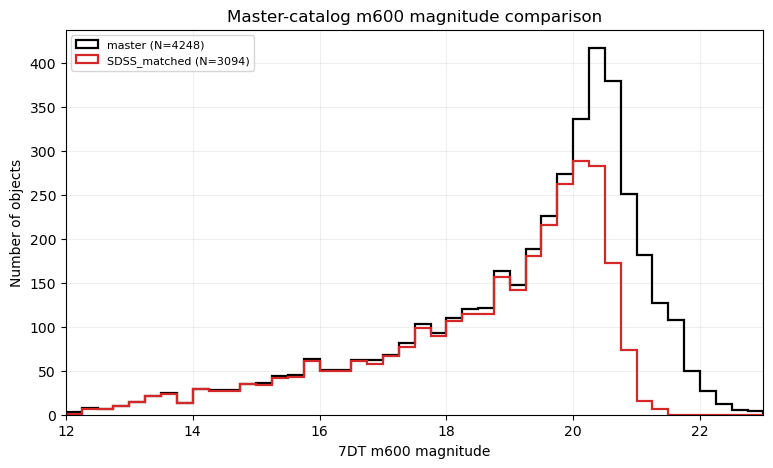

m600 [m600_mag_histogram_galaxy.png] counts:
master_excl_SDSS_star: N = 1964
 SDSS_matched_galaxy: N = 810


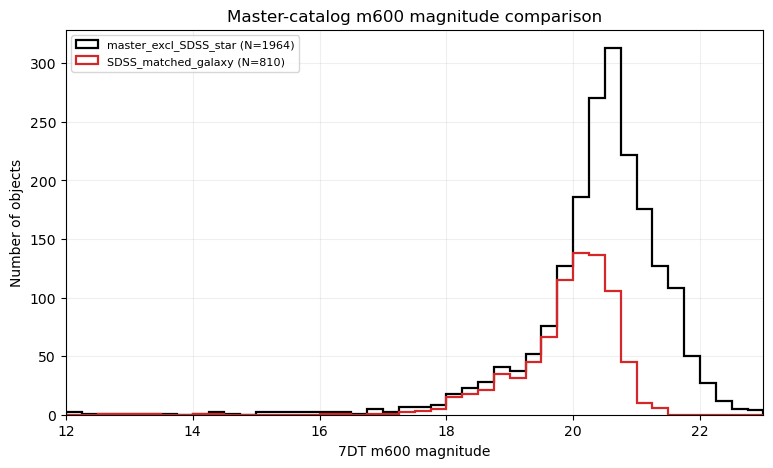

saved histograms for 20 bands x 2 versions to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/01_mag_histograms


In [5]:
# Magnitude histograms for every 7DT band (display: m600 only; all bands saved as PNG).
# Two versions per band, both saved:
#  (1) master vs SDSS_matched (has_sdss)
#  (2) master_excl_SDSS_star vs SDSS_matched_galaxy
#      master_excl_SDSS_star = valid & ~(has_sdss & sdss_type==6)
_sdss_type = np.ma.filled(master['sdss_type'], -1).astype(int)
_sdss_matched = has_sdss_flag
_sdss_star = has_sdss_flag & (_sdss_type == 6)
_sdss_galaxy = has_sdss_flag & (_sdss_type == 3)
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    valid = np.isfinite(mag)
    master_excl_star = valid & ~_sdss_star
    versions = {
        f'{band}_mag_histogram.png': {
            'master': valid,
            'SDSS_matched': _sdss_matched & valid,
        },
        f'{band}_mag_histogram_galaxy.png': {
            'master_excl_SDSS_star': master_excl_star,
            'SDSS_matched_galaxy': _sdss_galaxy & valid,
        },
    }
    values = mag[valid]
    hist_range = (np.floor(np.nanpercentile(values, 0.5)), np.ceil(np.nanpercentile(values, 99.5)))
    bin_edges = np.arange(hist_range[0], hist_range[1] + 0.25, 0.25)
    for fname, conditions in versions.items():
        fig, ax = plt.subplots(figsize=(9, 5))
        keys = list(conditions.keys())
        ax.hist(mag[conditions[keys[0]]], bins=bin_edges, histtype='step', color='black', linewidth=1.6,
                label=f"{keys[0]} (N={np.count_nonzero(conditions[keys[0]])})")
        ax.hist(mag[conditions[keys[1]]], bins=bin_edges, histtype='step', linewidth=1.6,
                color='C3', label=f"{keys[1]} (N={np.count_nonzero(conditions[keys[1]])})")
        ax.set_xlim(*hist_range)
        ax.set_xlabel(f'7DT {band} magnitude')
        ax.set_ylabel('Number of objects')
        ax.set_title(f'Master-catalog {band} magnitude comparison')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
        fig.savefig(HIST_DIR / fname, dpi=150, bbox_inches='tight')
        if band == 'm600':
            print(f'{band} [{fname}] counts:')
            for name, cond in conditions.items():
                print(f'{name:>20s}: N = {np.count_nonzero(cond)}')
            plt.show()
        else:
            plt.close(fig)
print(f'saved histograms for {N_ACTIVE_BANDS} bands x 2 versions to {HIST_DIR}')


## m600 magnitude-S/N depth diagnostics

Sample is `7DT_only` union `matched`; S/N is `1.0857 / mag_err`. All bands are saved; `m600` is shown with full and `0 <= S/N <= 10` rows.


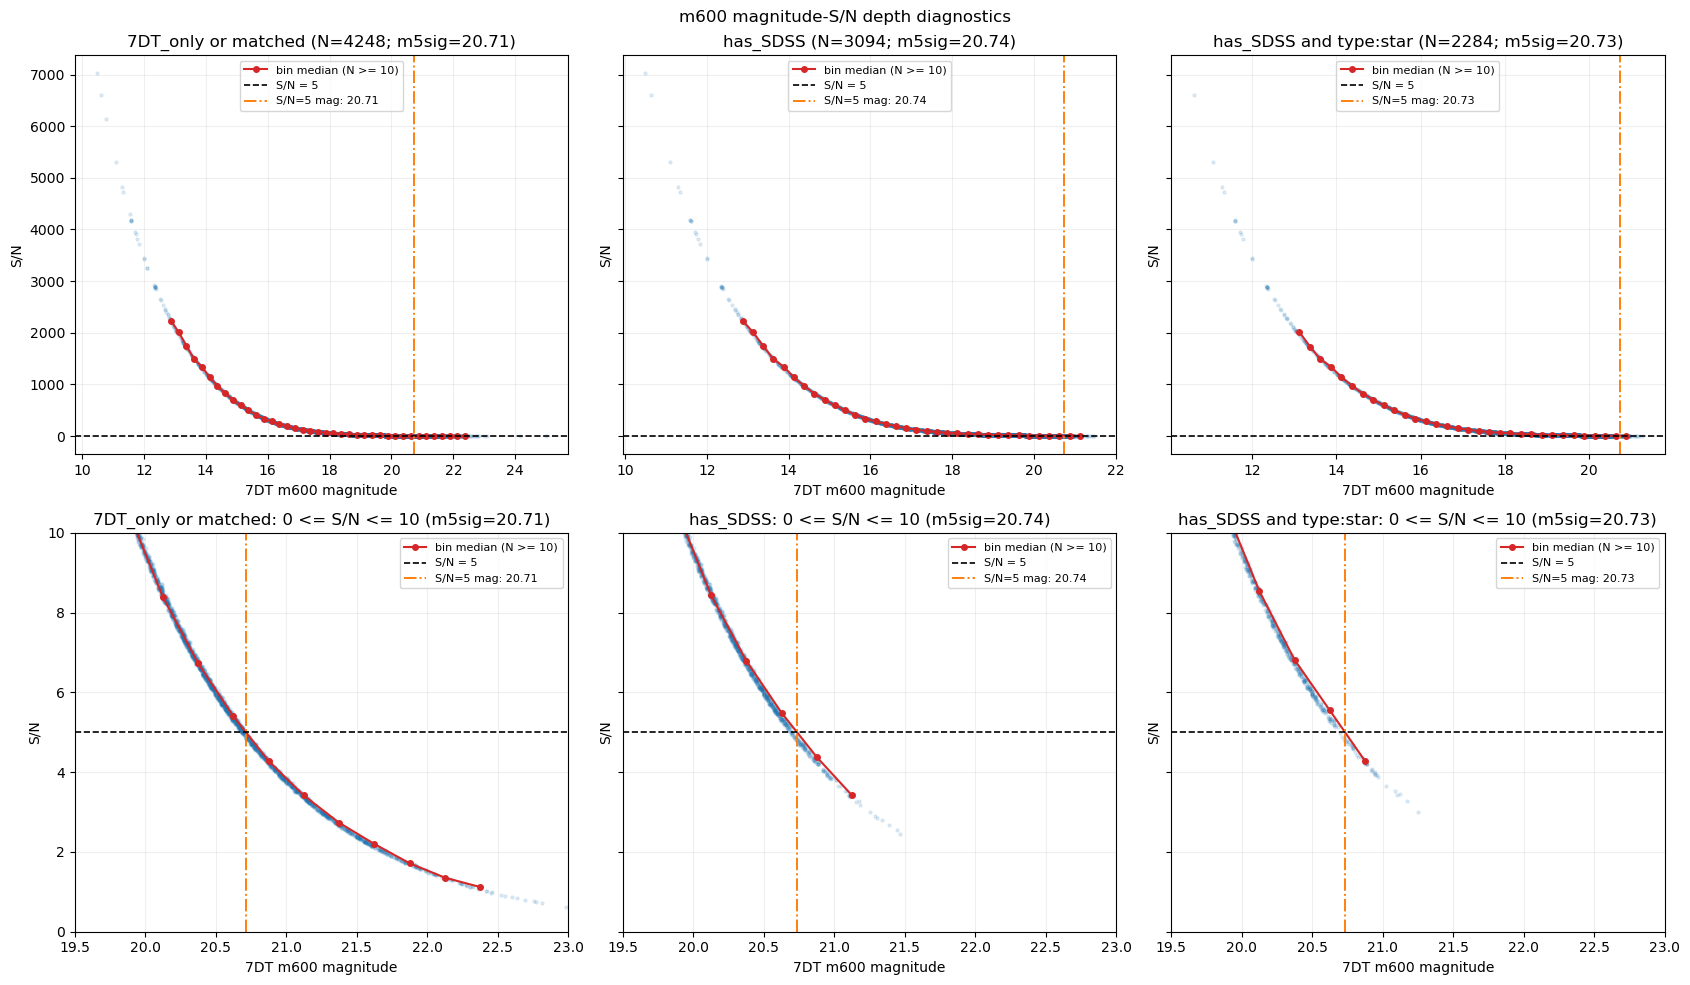

Magnitude-S/N population counts and S/N=5 limiting magnitudes:
     7DT_only or matched: N = 4248, m5sig = 20.71
                has_SDSS: N = 3094, m5sig = 20.74
  has_SDSS and type:star: N = 2284, m5sig = 20.73


band  m5sig(all)  m5sig(has_SDSS)  m5sig(star)
m400  21.26  21.27  21.29
m425  22.01  22.02  22.03
m450  21.28  21.29  21.27
m475  21.91  21.93  21.93
m500  21.55  21.56  21.58
m525  21.99  22.00  22.01
m550  20.89  20.91  20.91
m575  21.57  21.58  21.58
m600  20.71  20.74  20.73
m625  21.19  21.20  21.19
m650  20.22  20.24  20.25
m675  21.40  21.41  21.41
m700  20.61  20.62  20.60
m725  20.81  20.83  20.83
m750  20.18  20.20  20.19
m775  20.24  20.27  20.26
m800  19.90  19.91  19.91
m825  19.71  19.72  19.72
m850  19.48  19.50  19.51
m875  19.06  19.09  19.11
saved magnitude-S/N figures for 20 bands to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/02_mag_snr


In [6]:
# Magnitude-S/N diagnostics for every 7DT band (display: m600 only; all bands saved as PNG).
def _sn5_limit(centers, medians, level=5.0):
    # Median S/N falls with magnitude; linearly interpolate the bright-to-faint
    # crossing of the S/N = level line. Returns nan when there is no crossing.
    c = np.asarray(centers, dtype=float)
    m = np.asarray(medians, dtype=float)
    ok = np.isfinite(c) & np.isfinite(m)
    c, m = c[ok], m[ok]
    if c.size < 2:
        return np.nan
    order = np.argsort(c)
    c, m = c[order], m[order]
    below = np.where(m < level)[0]
    if below.size == 0 or np.all(m < level):
        return np.nan
    i = int(below[0])
    if i == 0 or not (m[i - 1] >= level > m[i]):
        return np.nan
    c0, m0, c1, m1 = c[i - 1], m[i - 1], c[i], m[i]
    return float(c0 + (level - m0) * (c1 - c0) / (m1 - m0))

def _depth_figure(band, mag, snr, base, save_path=None, show=False):
    conds = {
        '7DT_only or matched': base,
        'has_SDSS': base & has_sdss_flag,
        'has_SDSS and type:star': base & sdss_star,
    }
    bins = np.arange(np.floor(np.nanmin(mag[base])), np.ceil(np.nanmax(mag[base])) + 0.25, 0.25)
    # Per-population bin medians and S/N=5 limiting magnitudes.
    locus, m5 = {}, {}
    for name, cond in conds.items():
        x, y = mag[cond], snr[cond]
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            # Require at least 10 sources so sparse bins do not drive depth estimates.
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(y[sel]))
        locus[name] = (x, y, centers, medians)
        m5[name] = _sn5_limit(centers, medians)
    fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharey='row')
    crop = mag[base & (snr >= 0) & (snr <= 10)]
    crop_xlim = (np.floor(np.nanpercentile(crop, 0.5) * 2) / 2, np.ceil(np.nanpercentile(crop, 99.5) * 2) / 2)
    for col, (name, cond) in enumerate(conds.items()):
        x, y, centers, medians = locus[name]
        lim = m5[name]
        for row in range(2):
            ax = axes[row, col]
            ax.scatter(x, y, s=5, alpha=0.12, color='C0', rasterized=True)
            ax.plot(centers, medians, 'o-', color='C3', markersize=4, linewidth=1.5, label='bin median (N >= 10)')
            ax.axhline(5, color='black', linestyle='--', linewidth=1.2, label='S/N = 5')
            if np.isfinite(lim):
                ax.axvline(lim, color='C1', linestyle='-.', linewidth=1.4, label=f'S/N=5 mag: {lim:.2f}')
            ax.set_xlabel(f'7DT {band} magnitude')
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8)
        tag = f'm5sig={lim:.2f}' if np.isfinite(lim) else 'm5sig=n/a'
        axes[0, col].set_title(f'{name} (N={np.count_nonzero(cond)}; {tag})')
        axes[0, col].set_ylabel('S/N')
        axes[1, col].set_ylim(0, 10)
        axes[1, col].set_xlim(*crop_xlim)
        axes[1, col].set_title(f'{name}: 0 <= S/N <= 10 ({tag})')
        axes[1, col].set_ylabel('S/N')
    fig.suptitle(f'{band} magnitude-S/N depth diagnostics')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return conds, m5

depth_rows = []
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    err = _finite_column(master, f'{band}_mag_err')
    snr = 1.0857 / err
    valid = np.isfinite(mag)
    base = np.isin(master_class, ['7dt_only', 'matched']) & valid & np.isfinite(snr) & (err > 0)
    conds, m5 = _depth_figure(band, mag, snr, base, save_path=SNR_DIR / f'{band}_mag_snr.png', show=(band == 'm600'))
    depth_rows.append((band, *(m5[k] for k in ['7DT_only or matched', 'has_SDSS', 'has_SDSS and type:star'])))
    if band == 'm600':
        print('Magnitude-S/N population counts and S/N=5 limiting magnitudes:')
        for name, cond in conds.items():
            print(f'{name:>24s}: N = {np.count_nonzero(cond)}, m5sig = {m5[name]:.2f}')
print('band  m5sig(all)  m5sig(has_SDSS)  m5sig(star)')
for band, a, b, c in depth_rows:
    print(f'{band}  {a:.2f}  {b:.2f}  {c:.2f}')
print(f'saved magnitude-S/N figures for {N_ACTIVE_BANDS} bands to {SNR_DIR}')


## FWHM-magnitude diagnostics (per band)

FWHM proxy is `2 x flux_radius` (pix), the same definition as `band_uncertainty['fwhm_pix'] = 2 x r50_med`. 
Sample is `7dt_only` union `matched` with finite mag / positive mag_err / finite positive `flux_radius`, 
split into the same three populations as the S/N section. 
Horizontal dashed line marks the per-band PSF reference from `band_uncertainty.fits`. 
All bands are saved under `04_fwhm_mag`; `m600` is shown.


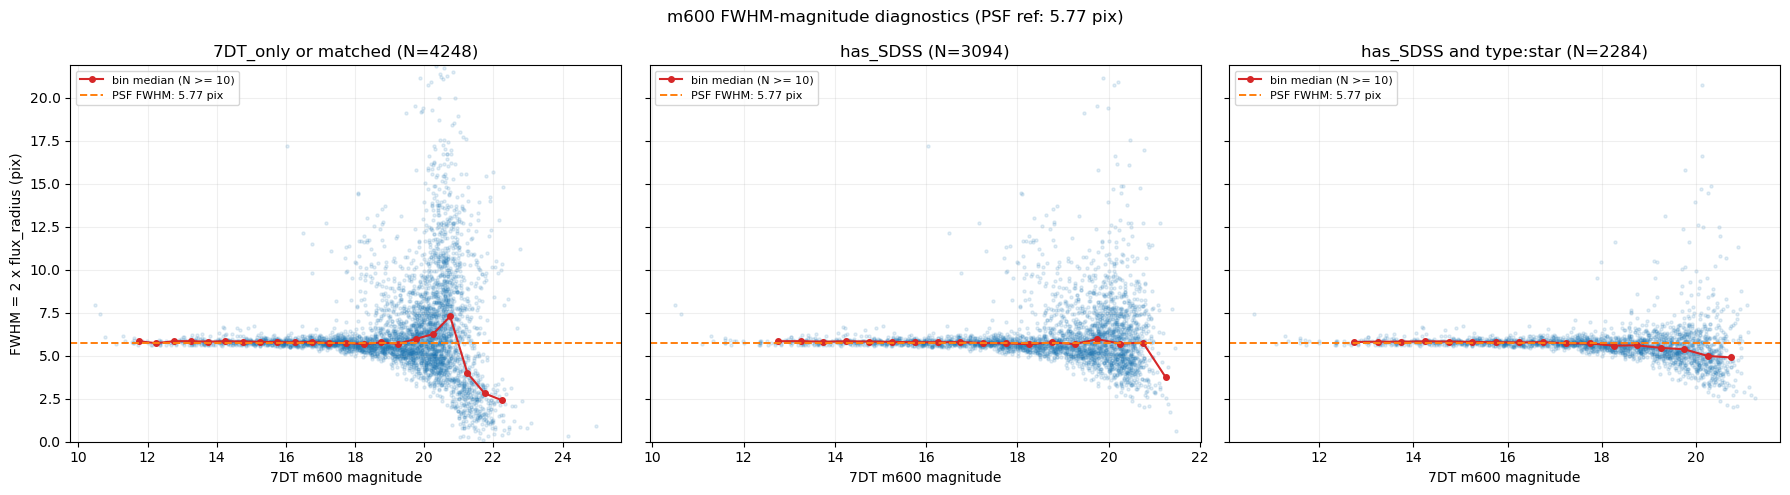

FWHM-mag population counts (m600):
     7DT_only or matched: N = 4248
                has_SDSS: N = 3094
  has_SDSS and type:star: N = 2284


band  psf_fwhm_pix  N_all  N_has_SDSS  N_star  med_fwhm_all_pix
m400  5.25   3171   1615   1431  5.30
m425  5.83   4292   2732   2071  5.89
m450  5.76   3658   2378   1988  5.81
m475  6.10   5171   3688   2594  6.17
m500  4.97   4983   3529   2568  5.05
m525  5.51   6850   5132   3119  5.60
m550  6.23   3963   2768   2177  6.26
m575  6.59   6217   4502   2892  6.66
m600  5.77   4248   3094   2284  5.80
m625  5.73   6173   4649   2902  5.79
m650  5.26   3879   2852   2290  5.30
m675  5.14   7984   6087   3469  5.27
m700  5.88   5001   3602   2605  5.97
m725  6.10   5852   4279   2906  6.20
m750  5.05   5047   3834   2885  5.10
m775  5.31   5394   3950   2899  5.36
m800  5.80   4461   3230   2556  5.88
m825  6.38   4113   2918   2391  6.44
m850  4.97   4194   2960   2444  5.04
m875  5.66   3473   2359   2072  5.72
saved FWHM-magnitude figures for 20 bands to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/depth_by_band/04_fwhm_mag


In [7]:
# FWHM-magnitude diagnostics for every 7DT band (display: m600 only; all bands saved as PNG).
FWHM_DIR = DEPTH_FIG_DIR / '04_fwhm_mag'
FWHM_DIR.mkdir(parents=True, exist_ok=True)

# Per-band PSF reference: fwhm_pix = 2 x r50_med (same definition as 2 x flux_radius).
_unc_path = MATCH_DIR / 'band_uncertainty.fits'
_unc = Table.read(_unc_path)
_unc_bands = _unc['band']
PSF_FWHM_PIX = {}
for _b, _f in zip(_unc_bands, _unc['fwhm_pix']):
    _b = _b.decode().strip() if isinstance(_b, (bytes, np.bytes_)) else str(_b).strip()
    PSF_FWHM_PIX[_b] = float(_f)

def _fwhm_figure(band, mag, fwhm, base, psf_fwhm, save_path=None, show=False):
    conds = {
        '7DT_only or matched': base,
        'has_SDSS': base & has_sdss_flag,
        'has_SDSS and type:star': base & sdss_star,
    }
    bins = np.arange(np.floor(np.nanmin(mag[base])), np.ceil(np.nanmax(mag[base])) + 0.5, 0.5)
    locus = {}
    for name, cond in conds.items():
        x, y = mag[cond], fwhm[cond]
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(y[sel]))
        locus[name] = (x, y, centers, medians)
    lo, hi = np.nanpercentile(fwhm[base], [0.5, 99.5])
    pad = 0.1 * (hi - lo) if np.isfinite(hi - lo) and hi > lo else 1.0
    ylim = (max(0.0, lo - pad), hi + pad)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (name, cond) in zip(axes, conds.items()):
        x, y, centers, medians = locus[name]
        ax.scatter(x, y, s=5, alpha=0.12, color='C0', rasterized=True)
        ax.plot(centers, medians, 'o-', color='C3', markersize=4, linewidth=1.5, label='bin median (N >= 10)')
        if np.isfinite(psf_fwhm):
            ax.axhline(psf_fwhm, color='C1', linestyle='--', linewidth=1.4, label=f'PSF FWHM: {psf_fwhm:.2f} pix')
        ax.set_xlabel(f'7DT {band} magnitude')
        ax.set_title(f'{name} (N={np.count_nonzero(cond)})')
        ax.set_ylim(*ylim)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
    axes[0].set_ylabel('FWHM = 2 x flux_radius (pix)')
    fig.suptitle(f'{band} FWHM-magnitude diagnostics (PSF ref: {psf_fwhm:.2f} pix)')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return conds

fwhm_rows = []
for band in ACTIVE_BANDS:
    mag = _finite_column(master, f'{band}_mag')
    err = _finite_column(master, f'{band}_mag_err')
    fr = _finite_column(master, f'{band}_flux_radius')
    fwhm = 2.0 * fr
    valid = np.isfinite(mag) & np.isfinite(fwhm) & (fwhm > 0) & np.isfinite(err) & (err > 0)
    base = np.isin(master_class, ['7dt_only', 'matched']) & valid
    psf = PSF_FWHM_PIX.get(band, np.nan)
    conds = _fwhm_figure(band, mag, fwhm, base, psf, save_path=FWHM_DIR / f'{band}_fwhm_mag.png', show=(band == 'm600'))
    _med = float(np.nanmedian(fwhm[base])) if np.count_nonzero(base) else float('nan')
    fwhm_rows.append((band, psf, *(np.count_nonzero(conds[k]) for k in ['7DT_only or matched', 'has_SDSS', 'has_SDSS and type:star']), _med))
    if band == 'm600':
        print('FWHM-mag population counts (m600):')
        for name, cond in conds.items():
            print(f'{name:>24s}: N = {np.count_nonzero(cond)}')
print('band  psf_fwhm_pix  N_all  N_has_SDSS  N_star  med_fwhm_all_pix')
for band, psf, na, nb_, nc, med in fwhm_rows:
    print(f'{band}  {psf:.2f}  {na:5d}  {nb_:5d}  {nc:5d}  {med:.2f}')
print(f'saved FWHM-magnitude figures for {N_ACTIVE_BANDS} bands to {FWHM_DIR}')


## SDSS versus 7DT consistency (nearest band)

Each 7DT band is compared with its nearest SDSS band. All bands are saved; `m600` is shown.


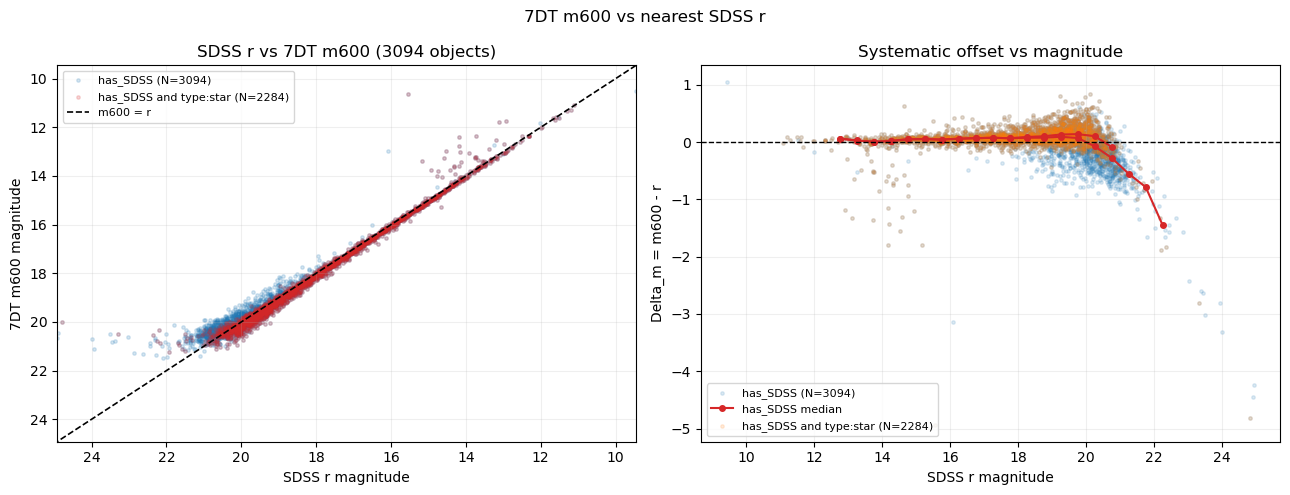

band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star
m400     u   1615  -0.7182  0.4896  0.2856   1431  -0.7051  0.3746  0.2705
m425     g   2732  +0.4328  0.4567  0.3709   2071  +0.5254  0.4068  0.3457
m450     g   2378  +0.0752  0.3453  0.1369   1988  +0.0914  0.2737  0.1078
m475     g   3688  -0.1480  0.3240  0.1682   2594  -0.1114  0.2616  0.1117
m500     g   3529  -0.1909  0.3402  0.1923   2568  -0.1458  0.2726  0.1108
m525     g   5132  -0.5117  0.3607  0.3695   3119  -0.3305  0.3095  0.2323
m550     r   2768  +0.2450  0.3730  0.2498   2177  +0.3082  0.3052  0.2247
m575     r   4502  +0.0994  0.3285  0.2186   2892  +0.1580  0.2573  0.1364
m600     r   3094  +0.0374  0.3628  0.1615   2284  +0.0696  0.2614  0.0973
m625     r   4649  -0.0727  0.3529  0.2149   2902  -0.0126  0.2559  0.0881
m650     r   2852  -0.1829  0.3354  0.2297   2290  -0.1233  0.2722  0.1627
m675     r   6087  -0.2680  0.3292  0.2615   3469  -0.1631  0.2527  0.1356
m700     i   3602

In [8]:
# SDSS consistency for every 7DT band vs nearest SDSS band (display: m600 only; all bands saved as PNG).
import math
rows = []
for band in ACTIVE_BANDS:
    sband = BAND_SDSS_MATCH[band]
    mag = _finite_column(master, f'{band}_mag')
    sdss_mag = _finite_column(master, f'sdss_psfMag_{sband}')
    valid = has_sdss_flag & np.isfinite(mag) & np.isfinite(sdss_mag)
    star_sel = valid & sdss_star
    delta = mag - sdss_mag
    def _stats(v):
        v = v[np.isfinite(v)]
        if len(v) == 0:
            return (0, math.nan, math.nan, math.nan)
        med = float(np.nanmedian(v))
        return (len(v), med, float(np.nanstd(v)), float(1.4826 * np.nanmedian(np.abs(v - med))))
    n_all, med_all, std_all, mad_all = _stats(delta[valid])
    n_star, med_star, std_star, mad_star = _stats(delta[star_sel])
    rows.append((band, sband, n_all, med_all, std_all, mad_all, n_star, med_star, std_star, mad_star))
    # Scatter + Delta plots.
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    for cond, label, color in [(valid, 'has_SDSS', 'C0'), (star_sel, 'has_SDSS and type:star', 'C3')]:
        axes[0].scatter(sdss_mag[cond], mag[cond], s=6, alpha=0.18, color=color,
                        label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
    lo = float(np.nanmin(np.concatenate([sdss_mag[valid], mag[valid]])))
    hi = float(np.nanmax(np.concatenate([sdss_mag[valid], mag[valid]])))
    axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label=f'{band} = {sband}')
    axes[0].set(xlim=(lo, hi), ylim=(lo, hi), xlabel=f'SDSS {sband} magnitude', ylabel=f'7DT {band} magnitude')
    axes[0].invert_xaxis(); axes[0].invert_yaxis()
    axes[0].set_title(f'SDSS {sband} vs 7DT {band} ({n_all} objects)')
    axes[0].grid(alpha=0.2); axes[0].legend(fontsize=8)
    for cond, label in [(valid, 'has_SDSS'), (star_sel, 'has_SDSS and type:star')]:
        x, d = sdss_mag[cond], delta[cond]
        axes[1].scatter(x, d, s=6, alpha=0.15, label=f'{label} (N={np.count_nonzero(cond)})', rasterized=True)
        bins = np.arange(np.floor(np.nanmin(x)), np.ceil(np.nanmax(x)) + 0.5, 0.5)
        centers, medians = [], []
        for left, right in zip(bins[:-1], bins[1:]):
            sel = (x >= left) & (x < right)
            if np.count_nonzero(sel) >= 10:
                centers.append((left + right) / 2)
                medians.append(np.nanmedian(d[sel]))
        axes[1].plot(centers, medians, 'o-', color='C3', markersize=4, label=f'{label} median' if label == 'has_SDSS' else None)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set(xlabel=f'SDSS {sband} magnitude', ylabel=f'Delta_m = {band} - {sband}')
    axes[1].set_title(f'Systematic offset vs magnitude')
    axes[1].grid(alpha=0.2); axes[1].legend(fontsize=8)
    fig.suptitle(f'7DT {band} vs nearest SDSS {sband}')
    fig.tight_layout()
    fig.savefig(CONSISTENCY_DIR / f'{band}_vs_sdss_{sband}_consistency.png', dpi=150, bbox_inches='tight')
    if band == 'm600':
        plt.show()
    else:
        plt.close(fig)
print('band  sdss  N_all  med_all  std_all  mad_all  N_star  med_star  std_star  mad_star')
for r in rows:
    print(f"{r[0]}  {r[1]:>4s}  {r[2]:5d}  {r[3]:+.4f}  {r[4]:.4f}  {r[5]:.4f}  {r[6]:5d}  {r[7]:+.4f}  {r[8]:.4f}  {r[9]:.4f}")
print(f'saved SDSS-consistency figures for {N_ACTIVE_BANDS} bands to {CONSISTENCY_DIR}')


In [9]:
def plot_ImageAndDetectedSources(
    image, cat, center_point=None, length=None,
    x_column='master_x', y_column='master_y',
    source_color='red', title=None, output_filename=None,
):
    '''Plot an image cutout and catalog source positions.'''
    required = {x_column, y_column}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f'Catalog is missing required columns: {sorted(missing)}')
    if (center_point is None) != (length is None):
        raise ValueError('center_point and length must be provided together.')
    if center_point is None:
        xmin, ymin, xmax, ymax = 0, 0, image.shape[1], image.shape[0]
    else:
        half = float(length) / 2.0
        xmin = max(0, int(np.floor(center_point[0] - half)))
        xmax = min(image.shape[1], int(np.ceil(center_point[0] + half)))
        ymin = max(0, int(np.floor(center_point[1] - half)))
        ymax = min(image.shape[0], int(np.ceil(center_point[1] + half)))
    if xmax <= xmin or ymax <= ymin:
        raise ValueError('The requested cutout is empty.')
    x = np.ma.filled(cat[x_column], np.nan).astype(float)
    y = np.ma.filled(cat[y_column], np.nan).astype(float)
    finite = np.isfinite(x) & np.isfinite(y) & (x >= xmin) & (x < xmax) & (y >= ymin) & (y < ymax)
    figure, axis = plt.subplots(figsize=(10, 10))
    image_plot = image[ymin:ymax, xmin:xmax]
    axis.imshow(image_plot, origin='lower', cmap='gray', norm=ImageNormalize(image_plot, interval=ZScaleInterval()), extent=[xmin, xmax, ymin, ymax])
    axis.scatter(x[finite], y[finite], s=36, facecolors='none', edgecolors=source_color, linewidths=0.8, label=f'detected sources ({int(finite.sum())})', rasterized=True)
    if center_point is not None:
        axis.axhline(center_point[1], color='cyan', linestyle='--', linewidth=0.8)
        axis.axvline(center_point[0], color='cyan', linestyle='--', linewidth=0.8)
    axis.set(xlabel='X pixel', ylabel='Y pixel')
    if title is not None:
        axis.set_title(title)
    axis.legend(loc='upper right')
    figure.tight_layout()
    if output_filename is not None:
        figure.savefig(output_filename, dpi=160, bbox_inches='tight')
    return figure, axis, int(finite.sum())


In [10]:
def plot_SourceImgFromCatalog(cat, image=None, pixel_range=None, source_id=None, show=True):
    # Plot a catalog on the detection image, optionally centered on one source.
    if image is None:
        image = detection_image
    if len(cat) == 0:
        raise ValueError("The input catalog is empty.")
    required = {"master_id", "master_x", "master_y"}
    missing = required.difference(cat.colnames)
    if missing:
        raise KeyError(f"Catalog is missing required columns: {sorted(missing)}")
    if pixel_range is not None and (not np.isfinite(pixel_range) or pixel_range <= 0):
        raise ValueError("pixel_range must be None or a positive number.")

    master_ids = np.asarray(cat["master_id"], dtype=np.int64)
    if source_id is None:
        rng = np.random.default_rng()
        selected_index = int(rng.integers(len(cat)))
    else:
        matches = np.flatnonzero(master_ids == int(source_id))
        if len(matches) == 0:
            raise KeyError(f"master_id={source_id} is not present in the catalog.")
        selected_index = int(matches[0])

    x_all = np.ma.filled(cat["master_x"], np.nan).astype(float)
    y_all = np.ma.filled(cat["master_y"], np.nan).astype(float)
    selected_x = float(x_all[selected_index])
    selected_y = float(y_all[selected_index])
    if not np.isfinite(selected_x) or not np.isfinite(selected_y):
        raise ValueError("The selected source has a non-finite pixel position.")

    if pixel_range is None:
        xmin, xmax = 0, image.shape[1]
        ymin, ymax = 0, image.shape[0]
    else:
        center_x = int(round(selected_x - 1))
        center_y = int(round(selected_y - 1))
        half = int(round(pixel_range))
        xmin = max(0, center_x - half)
        xmax = min(image.shape[1], center_x + half + 1)
        ymin = max(0, center_y - half)
        ymax = min(image.shape[0], center_y + half + 1)

    finite = np.isfinite(x_all) & np.isfinite(y_all)
    in_view = finite & (
        (x_all - 1 >= xmin) & (x_all - 1 < xmax)
        & (y_all - 1 >= ymin) & (y_all - 1 < ymax)
    )
    crop = image[ymin:ymax, xmin:xmax]
    norm = ImageNormalize(image, interval=ZScaleInterval())
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(
        crop,
        origin="lower",
        cmap="gray",
        norm=norm,
        extent=[xmin + 0.5, xmax + 0.5, ymin + 0.5, ymax + 0.5],
    )

    default_color = "tab:red"
    class_colors = {"matched": "purple", "7dt_only": "tab:red", "finalcat_only": "tab:blue"}
    if "master_class" in cat.colnames:
        classes = np.asarray(cat["master_class"]).astype(str)
    else:
        classes = np.full(len(cat), "source", dtype="U16")
    for index in np.flatnonzero(in_view):
        ax.scatter(
            x_all[index], y_all[index], s=24, facecolors="none",
            edgecolors=class_colors.get(classes[index], default_color), linewidths=0.8,
        )

    ax.scatter(
        selected_x, selected_y, marker="+", s=180, color="cyan", linewidths=1.5,
        label=f"master_id={master_ids[selected_index]}",
    )
    ax.set_xlabel("X pixel")
    ax.set_ylabel("Y pixel")
    title_class = classes[selected_index]
    view_label = "whole image" if pixel_range is None else f"pixel_range={pixel_range}"
    ax.set_title(f"{title_class}: master_id={master_ids[selected_index]} ({view_label})")
    ax.legend(loc="upper right")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax, int(master_ids[selected_index])




Source information: master_id=20871
Image/catalog position
master_id master_class     master_ra          master_dec          master_x          master_y     n_7dt_bands has_finalcat has_sdss
--------- ------------ ------------------ ------------------ ------------------ ---------------- ----------- ------------ --------
    20871     7dt_only 149.99849357545685 2.0396354424390757 3686.3853981982516 4039.57303367968           8        False    False

Detection-image cutout


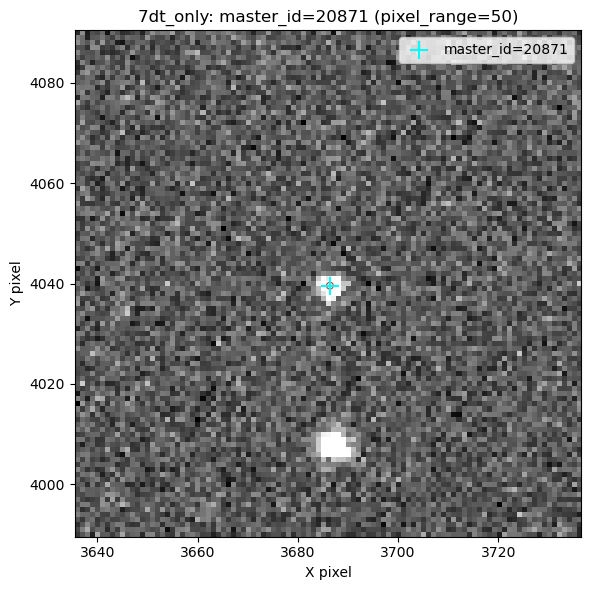


7DT 20-band cutouts


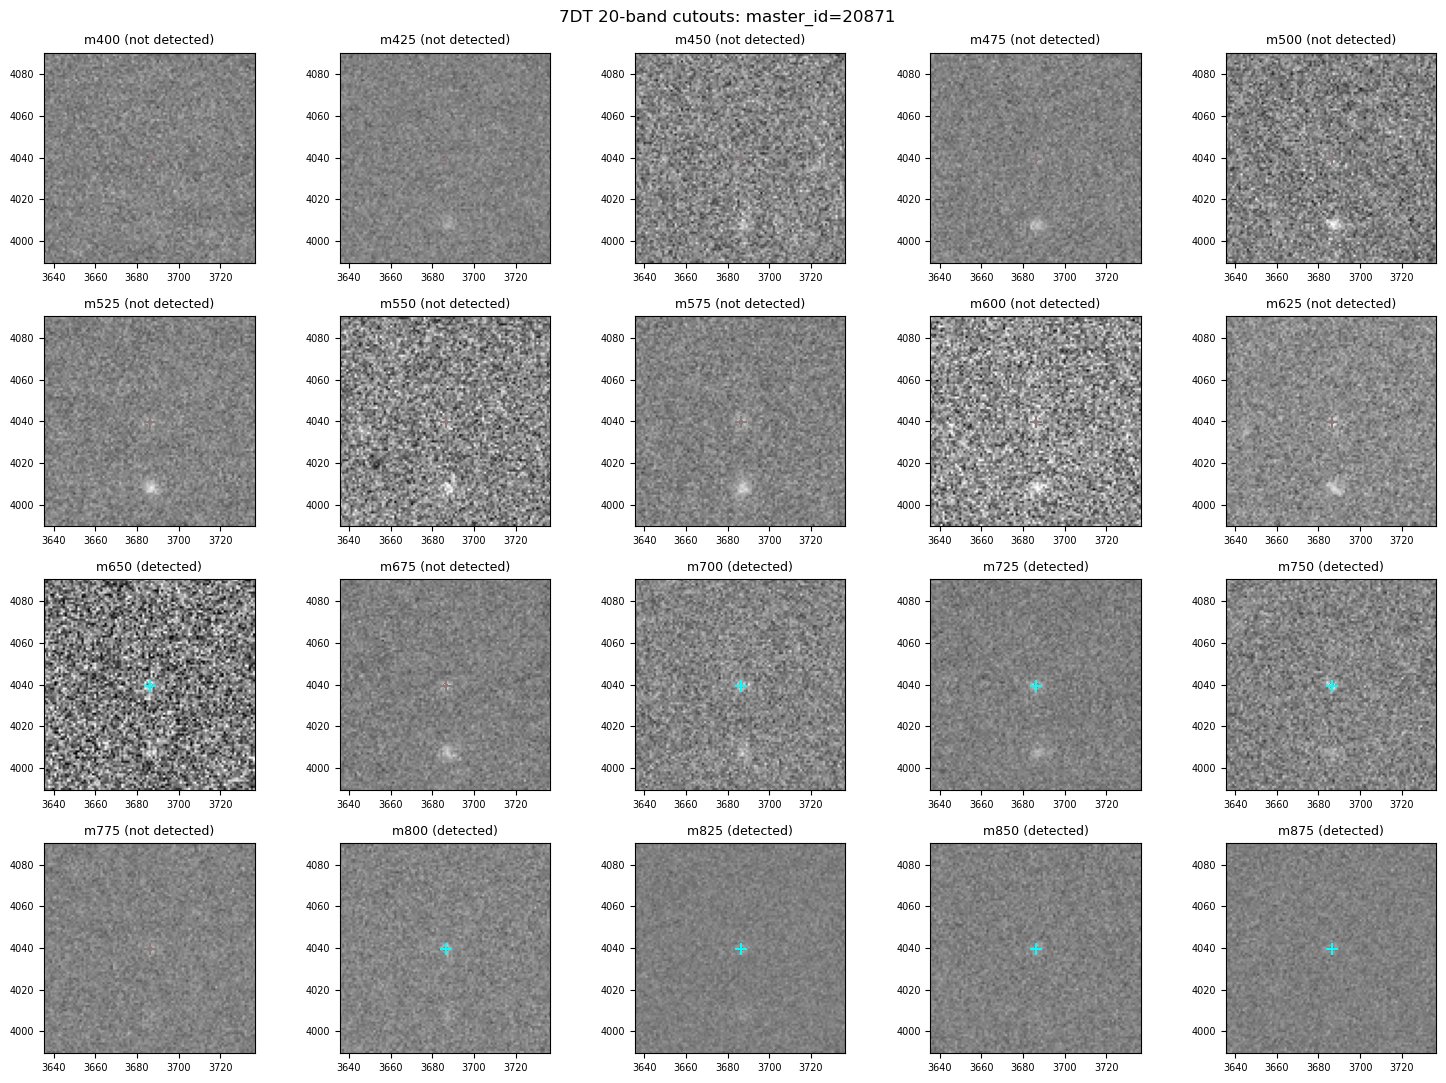

/var/folders/fd/sr9dc9td6rnc8xmntjxzpjh80000gn/T/ipykernel_58486/119309482.py:220: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].set(xlabel='m475 - m750', ylabel='m600', title='Color-magnitude diagram'); axes[0, 0].invert_yaxis(); axes[0, 0].legend(fontsize=8)
/var/folders/fd/sr9dc9td6rnc8xmntjxzpjh80000gn/T/ipykernel_58486/119309482.py:225: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].set(xlabel='m475 - m600', ylabel='m600 - m750', title='Color-color diagram'); axes[0, 1].legend(fontsize=8)



7DT photometry and morphology
band wavelength_nm detected source_id        mag               mag_err              snr             ellipticity      flux_radius_pix    derived_fwhm_pix  derived_fwhm_arcsec   band_fwhm_pix     band_fwhm_arcsec     extendicity    
---- ------------- -------- --------- ------------------ ------------------- ------------------ ------------------- ------------------ ------------------ ------------------- ------------------ ------------------ ------------------
m400           400    False        -1                nan                 nan                nan                 nan                nan                nan                 nan  5.249150991439819  2.650821250677528                nan
m425           425    False        -1                nan                 nan                nan                 nan                nan                nan                 nan   5.82735538482666 2.9428144693379292                nan
m450           450    False        -1        

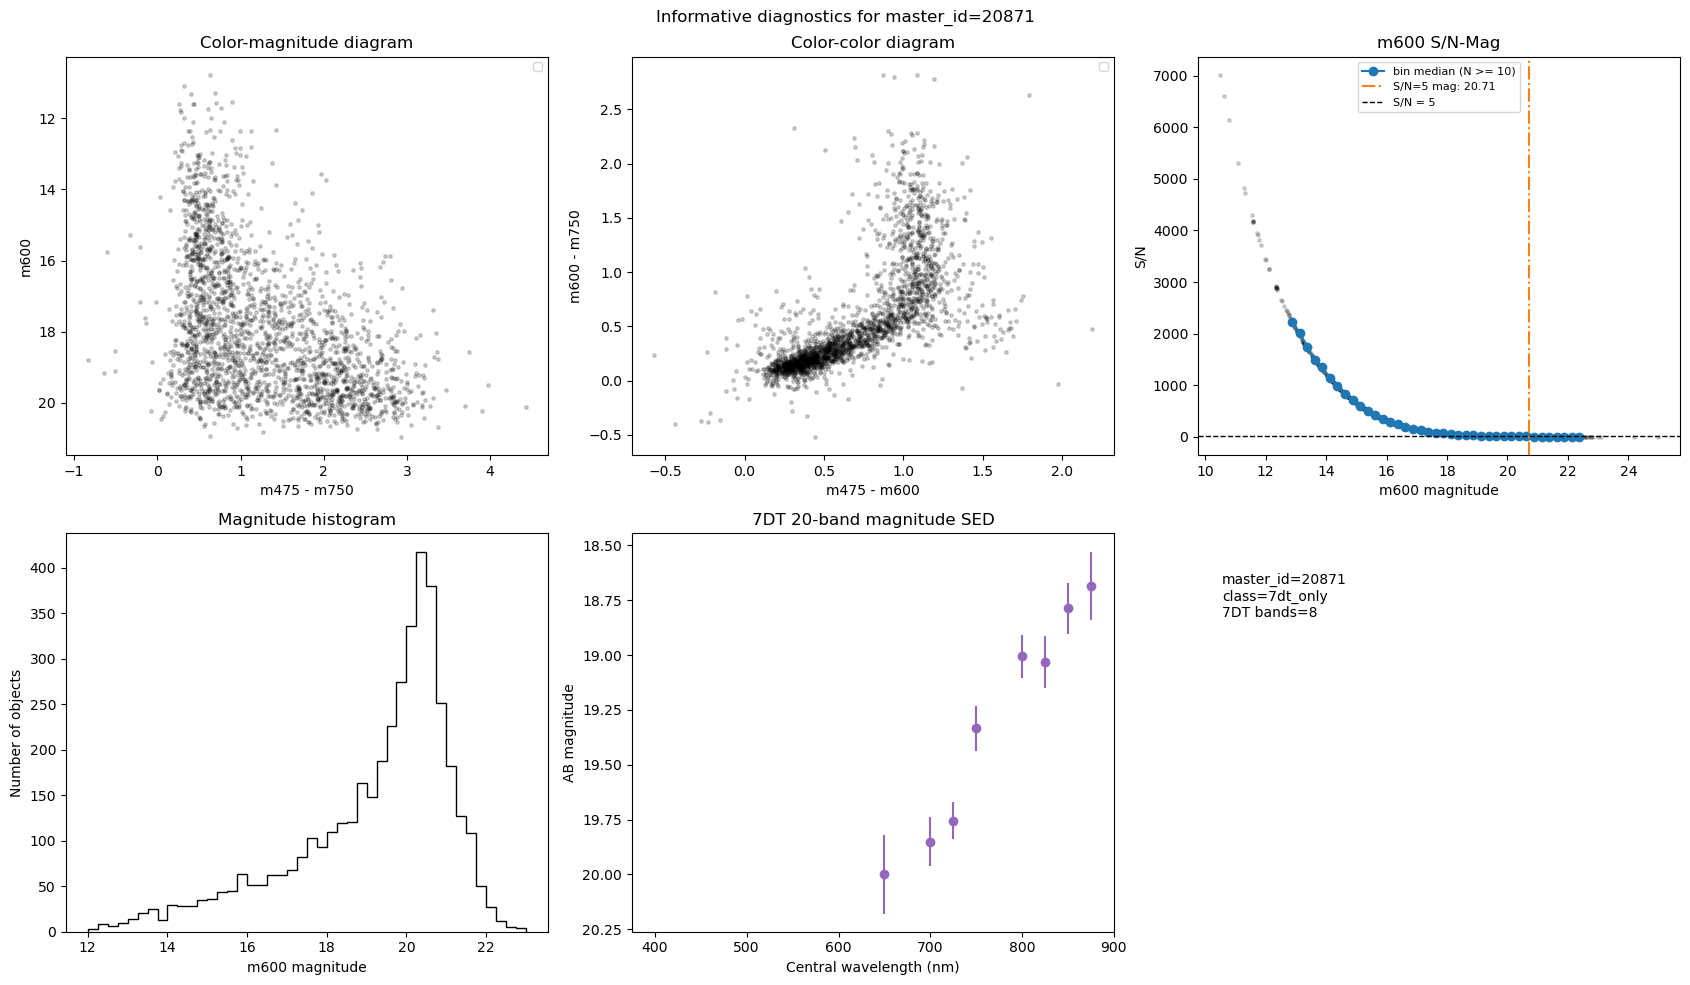

In [11]:
# print(f'Number of catalogs with 20 bands: {len(cat_has_20bands)}')
# cat_has_20bands_no_sdss = cat_has_20bands[cat_has_20bands['has_sdss'] == False]
# print(f'Number of catalogs not matched to SDSS in with20bands: {len(cat_has_20bands_no_sdss)}')
# print()
# source_info = plot_SourceInfoFromCatalog(
#     cat_has_20bands_no_sdss, 
#     pixel_range=50,
#     population_catalog=master,
#     source_id=721,
# )

cat_7dt_only_no_sdss = cat_7dt_only[cat_7dt_only['has_sdss'] == False]

source_info = plot_SourceInfoFromCatalog(
    cat_7dt_only_no_sdss, 
    pixel_range=50,
    population_catalog=master,
)

In [12]:
cat = cat_sdss_matched[cat_sdss_matched['sdss_type']==3]
print(len(cat))

4581


# SDSS Coverage and 7DT Recovery Analysis

## SDSS Galaxy Recovery as a Function of Magnitude

The canonical valid mask already removes 50 pixels from the irregular common-weight boundary. SDSS DR17 primary galaxies inside this mask form the reference population; recovered galaxies are those associated with a 7DT-bearing master source.


SDSS full-list catalog: 25771 rows -> /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/sdss_coverage_with_7dt_match_cosmos1_dr17.fits
in coverage: 23780, galaxy reference: 14069, master-matched: 16997, 7DT-matched: 9113
SDSS coverage mask and galaxy recovery summary
          quantity                value       
--------------------------- ------------------
       edge buffer (pixels)               50.0
       edge buffer (arcsec) 25.250000000003997
       coverage area (deg2) 1.0106037623749342
      SDSS primary galaxies            14069.0
7DT-recovered SDSS galaxies             4581.0
  overall recovery fraction 0.3256094960551567

Magnitude-binned recovery
sdss_r_center n_sdss_galaxy n_7dt_recovered recovery_fraction binomial_error
------------- ------------- --------------- ----------------- --------------
      13.1250             2               2            1.0000         0.0000
      13.3750             1               1            1.0000      

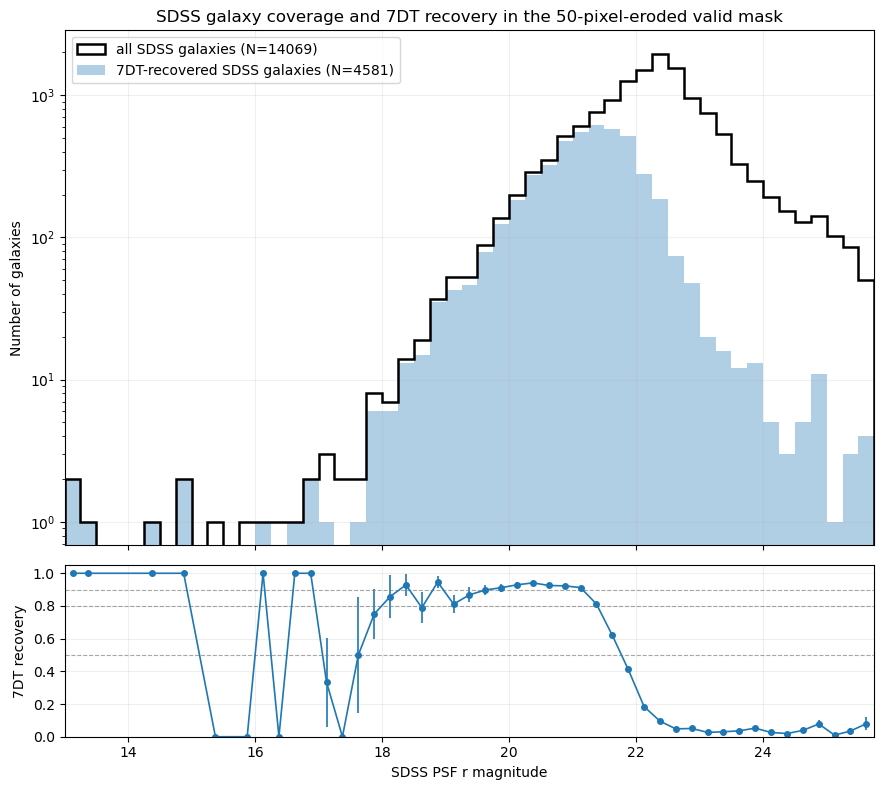


Saved SDSS coverage figure to /Users/mac_seo/Research_local/7DTonCOSMOS/output/COSMOS1/singlebandphot/matching/figures/sdss_coverage/sdss_galaxy_recovery_r.png


In [13]:
coverage_mask_path = DATA_ROOT / f'COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits'
coverage_mask = fits.getdata(coverage_mask_path).astype(bool)
coverage_mask_header = fits.getheader(coverage_mask_path)
COVERAGE_EDGE_BUFFER_PIXELS = int(coverage_mask_header.get('EDGEBUF', 0))
coverage_wcs = WCS(fits.getheader(get_image_path(COSMOS, REFERENCE_BAND)))
coverage_pixel_scale_arcsec = float(proj_plane_pixel_scales(coverage_wcs)[0] * 3600.0)
coverage_area_deg2 = float(coverage_mask.sum() * (coverage_pixel_scale_arcsec / 3600.0) ** 2)

sdss_coverage_path = MATCH_DIR / f'sdss_primary_cosmos{COSMOS}_dr17.fits'
sdss_coverage_all = Table.read(sdss_coverage_path)
sdss_x, sdss_y = coverage_wcs.all_world2pix(
    np.asarray(sdss_coverage_all['ra'], dtype=float),
    np.asarray(sdss_coverage_all['dec'], dtype=float),
    1,
)
sdss_ix = np.rint(sdss_x - 1).astype(int)
sdss_iy = np.rint(sdss_y - 1).astype(int)
sdss_inside_image = (
    np.isfinite(sdss_x) & np.isfinite(sdss_y)
    & (sdss_ix >= 0) & (sdss_ix < coverage_mask.shape[1])
    & (sdss_iy >= 0) & (sdss_iy < coverage_mask.shape[0])
)
sdss_in_coverage = np.zeros(len(sdss_coverage_all), dtype=bool)
sdss_in_coverage[sdss_inside_image] = coverage_mask[
    sdss_iy[sdss_inside_image], sdss_ix[sdss_inside_image]
]
sdss_r = np.ma.filled(sdss_coverage_all['psfMag_r'], np.nan).astype(float)
sdss_type = np.asarray(sdss_coverage_all['type'], dtype=int)
sdss_mode = np.asarray(sdss_coverage_all['mode'], dtype=int)
sdss_galaxy_reference = (
    sdss_in_coverage & (sdss_mode == 1) & (sdss_type == 3)
    & np.isfinite(sdss_r) & (sdss_r > -50) & (sdss_r < 50)
)

coverage_master = Table.read(MASTER_CATALOG_PATH)
master_has_sdss = np.asarray(coverage_master['has_sdss'], dtype=bool)
master_has_7dt = np.asarray(coverage_master['has_7dt'], dtype=bool)
master_sdss_galaxy = np.ma.filled(coverage_master['sdss_type'], -1).astype(int) == 3
recovered_sdss_ids = set(map(int, np.asarray(coverage_master['sdss_objid'])[
    master_has_sdss & master_has_7dt & master_sdss_galaxy
]))
sdss_galaxy_recovered = sdss_galaxy_reference & np.asarray([
    int(objid) in recovered_sdss_ids for objid in sdss_coverage_all['objid']
])

sdss_objids = np.asarray(sdss_coverage_all['objid']).astype(int)
master_sdss_objids = np.ma.filled(coverage_master['sdss_objid'], 0).astype(int)
master_ids = np.asarray(coverage_master['master_id']).astype(int)
master_match_status = np.asarray(coverage_master['sdss_match_status']).astype(str)
master_match_sep = np.ma.filled(coverage_master['sdss_sep_arcsec'], np.nan).astype(float)
sdss_to_master = {
    int(objid): (int(mid), bool(has7), str(status), float(sep))
    for objid, mid, has7, status, sep in zip(
        master_sdss_objids[master_has_sdss], master_ids[master_has_sdss],
        master_has_7dt[master_has_sdss], master_match_status[master_has_sdss],
        master_match_sep[master_has_sdss],
    )
}
matched_7dt_ids = set(map(int, master_sdss_objids[master_has_sdss & master_has_7dt]))
matched_any_ids = set(map(int, master_sdss_objids[master_has_sdss]))
sdss_has_master = np.asarray([objid in matched_any_ids for objid in sdss_objids])
sdss_has_7dt = np.asarray([objid in matched_7dt_ids for objid in sdss_objids])
sdss_catalog_path = MATCH_DIR / f'sdss_coverage_with_7dt_match_cosmos{COSMOS}_dr17.fits'
sdss_coverage_catalog = sdss_coverage_all.copy()
sdss_coverage_catalog['in_coverage_mask'] = sdss_in_coverage
sdss_coverage_catalog['is_galaxy_reference'] = sdss_galaxy_reference
sdss_coverage_catalog['has_master_match'] = sdss_has_master
sdss_coverage_catalog['has_7dt_match'] = sdss_has_7dt
sdss_coverage_catalog['master_id'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[0] for objid in sdss_objids])
sdss_coverage_catalog['master_has_7dt'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[1] for objid in sdss_objids])
sdss_coverage_catalog['master_match_status'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[2] for objid in sdss_objids])
sdss_coverage_catalog['master_sep_arcsec'] = np.asarray([sdss_to_master.get(objid, (-1, False, '', np.nan))[3] for objid in sdss_objids], dtype=float)
sdss_coverage_catalog.write(sdss_catalog_path, overwrite=True)
print(f'SDSS full-list catalog: {len(sdss_coverage_catalog)} rows -> {sdss_catalog_path}')
print(f'in coverage: {int(sdss_in_coverage.sum())}, galaxy reference: {int(sdss_galaxy_reference.sum())}, '
      f'master-matched: {int(sdss_has_master.sum())}, 7DT-matched: {int(sdss_has_7dt.sum())}')

reference_mag = sdss_r[sdss_galaxy_reference]
recovered_mag = sdss_r[sdss_galaxy_recovered]
hist_min = 13.0
hist_max = np.ceil(np.nanpercentile(reference_mag, 99.5) * 4) / 4
mag_bins = np.arange(hist_min, hist_max + 0.25, 0.25)
reference_count, _ = np.histogram(reference_mag, bins=mag_bins)
recovered_count, _ = np.histogram(recovered_mag, bins=mag_bins)
bin_centers = (mag_bins[:-1] + mag_bins[1:]) / 2
recovery_fraction = np.divide(
    recovered_count, reference_count,
    out=np.full(len(reference_count), np.nan), where=reference_count > 0,
)
recovery_error = np.sqrt(
    np.divide(
        recovery_fraction * (1 - recovery_fraction), reference_count,
        out=np.full(len(reference_count), np.nan), where=reference_count > 0,
    )
)

coverage_summary = Table(rows=[
    ('edge buffer (pixels)', COVERAGE_EDGE_BUFFER_PIXELS),
    ('edge buffer (arcsec)', COVERAGE_EDGE_BUFFER_PIXELS * coverage_pixel_scale_arcsec),
    ('coverage area (deg2)', coverage_area_deg2),
    ('SDSS primary galaxies', int(sdss_galaxy_reference.sum())),
    ('7DT-recovered SDSS galaxies', int(sdss_galaxy_recovered.sum())),
    ('overall recovery fraction', float(sdss_galaxy_recovered.sum() / sdss_galaxy_reference.sum())),
], names=['quantity', 'value'])
coverage_by_mag = Table(
    [bin_centers, reference_count, recovered_count, recovery_fraction, recovery_error],
    names=['sdss_r_center', 'n_sdss_galaxy', 'n_7dt_recovered', 'recovery_fraction', 'binomial_error'],
)
for name in ['sdss_r_center', 'recovery_fraction', 'binomial_error']:
    coverage_by_mag[name].format = '.4f'
print('SDSS coverage mask and galaxy recovery summary')
coverage_summary.pprint(max_width=10000)
print('\nMagnitude-binned recovery')
coverage_by_mag.pprint(max_width=10000)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].hist(reference_mag, bins=mag_bins, histtype='step', color='black', linewidth=1.8, label=f'all SDSS galaxies (N={len(reference_mag)})')
axes[0].hist(recovered_mag, bins=mag_bins, histtype='stepfilled', color='tab:blue', alpha=0.35, linewidth=1.4, label=f'7DT-recovered SDSS galaxies (N={len(recovered_mag)})')
axes[0].set_yscale('log')
axes[0].set_ylabel('Number of galaxies')
axes[0].set_title(f'SDSS galaxy coverage and 7DT recovery in the {COVERAGE_EDGE_BUFFER_PIXELS}-pixel-eroded valid mask')
axes[0].grid(alpha=0.2)
axes[0].legend()
valid_bin = reference_count > 0
axes[1].errorbar(bin_centers[valid_bin], recovery_fraction[valid_bin], yerr=recovery_error[valid_bin], fmt='o-', color='tab:blue', markersize=4, linewidth=1.2)
for level in (0.5, 0.8, 0.9): axes[1].axhline(level, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
axes[1].set(xlabel='SDSS PSF r magnitude', ylabel='7DT recovery', ylim=(0, 1.05), xlim=(hist_min, hist_max))
axes[1].grid(alpha=0.2)
fig.tight_layout()
coverage_figure_dir = MATCH_DIR / 'figures' / 'sdss_coverage'
coverage_figure_dir.mkdir(parents=True, exist_ok=True)
coverage_figure_path = coverage_figure_dir / 'sdss_galaxy_recovery_r.png'
fig.savefig(coverage_figure_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'\nSaved SDSS coverage figure to {coverage_figure_path}')
